[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/AjustamentoBasicoIME/blob/main/05_mmq_weighted.ipynb)

# Ajustamento Básico - MMQ ponderado
**Maj Diego - 2° Semestre / 2026**

**Objetivos:**

1. Formular e aplicar pesos às observações no MMQ
2. Formular o tratamento estatístico para análise do ajustamento

**Referência:**

Ghilani, C. D. (2017). *Adjustment computations: Spatial data analysis* (6th ed.). Wiley. $\rightarrow$ **Cap 10 e 25**

## O Problema

Até aqui, no ajustamento MMQ, a precisão do ajustamento/modelo é apenas informada ao final. Por exemplo, o caso abaixo:

$$
\begin{cases}
x = 10 \pm 0.1 \\
x = 14 \pm 5
\end{cases}
$$

$$x_a = 12 \ \ e \ \  \sigma_{x_a} = \sqrt{0.01^2 + 5^2} = 5.00000999999 $$

Como levar em consideração a precisão das observações durante o ajustamento?


## 1. Formular e aplicar pesos às observações no MMQ

### **1.1 Requisitos de uma matriz de pesos ($P$)**

- O peso de uma observação é uma medida do  <b style="color:#2ECC40">valor relativo dessa observação em comparação com outras observações</b>.
- Os pesos são usados para  <b style="color:#2ECC40">controlar as magnitudes das correções</b> aplicadas às observações em um ajustamento. 
- Quanto mais precisa for uma observação, maior deve ser o seu peso; em outras palavras, quanto menor a variância, maior o peso. 
- Intuitivamente, os pesos são  <b style="color:#2ECC40">inversamente proporcionais às variâncias</b>.

> Nota: Consideraremos daqui para frente, observações não correlacionadas (independentes), assim $\Sigma$ e $P$ serão sempre matrizes diagonais.

### **1.2 Uma possível matriz de pesos ($P$)**

Da discussão dos requisitos para a matriz de pesos, podemos definir $P$ relacionada com a inversa da matriz de covariância, $\Sigma$. Como os pesos são relativos, variâncias e covariâncias podem ser reescalonadas tais que:

$$w_{i} = \frac{\sigma^2_0}{\sigma_{i}}  \rightarrow P = \sigma^2_0 \Sigma^{-1}$$

onde $w_{i}$ é o peso da observação $i$, $\sigma_{i}$ a covariância da observação $i$, e $\sigma^2_0$ a variância de referência, um valor que pode ser usado para escala. 

### **1.3 MMQ ponderado**

Para encaixar essa matriz de pesos dentro do MMQ. Seja $AX = L$ um sistema linear:

| $\begin{matrix}\text{Não ponderado} & & \end{matrix}$ | $\begin{matrix}\text{Ponderado} & & \end{matrix}$  |
|- | - |
|$\small AX_a = L_a + V$ | $\small PAX_a = PL_a + PV$| 
|$\small \sum v_i^2 = V^TV = min$ | $\small \sum w_iv_i^2 = V^TPV = min$| 
|$\small X_a​=(A^TA)^{−1}A^TL$ | $\small X_a​=(A^TPA)^{−1}A^TPL$|

E sendo $F(X) = L$ um sistema não linear e $J$ a jacobiana de $F$ :

| $\begin{matrix}\text{Não ponderado} & & \end{matrix}$ | $\begin{matrix}\text{Ponderado} & & \end{matrix}$  |
|- | - |
|$\small F(X_0 + \Delta X) \approx F(X_0) + J \Delta X = L_b + V$ | $\small PF(X_0 + \Delta X) \approx PF(X_0) + PJ \Delta X = PL_b + PV$| 
|$\small \sum v_i^2 = V^TV = min$ | $\small \sum w_iv_i^2 = V^TPV = min$| 
|$\small \Delta X​=-(J^TJ)^{−1}J^TL$ | $\small  \Delta X​=-(J^TPJ)^{−1}J^TPL$|


**Exercício 01 (resolvido)** (Exercício 13.15 do livro GHILANI &amp; WOLF) O quadro e o esquema que se seguem resumem um nivelamento geométrico com referências de nível os pontos A e B, de altitude 263,453m e 294,837m respectivamente; as setas indicam o sentido da visada. Ajuste os desníveis pelo método dos mínimos quadrados paramétrico <b>considerando a precisão das observações indicada no quadro.</b>

<div > <img src="media/imgs/WolfProblem13-15esquema.png" height=300> <img src="media/imgs/WolfProblem13-15quadro.png" height=300></div>

In [4]:
import numpy as np


# Sistema linear {
# 263.453 V  25.102  +- 0.018
# 294.837 V  -6.287  +- 0.019
# V       X  10.987  +- 0.016
# V       Y  24.606  +- 0.021
# 294.837 Y  17.993  +- 0.017
# 263.453 X  36.085  +- 0.021
# Y       X  -13.295 +- 0.018
# Y       Z  -20.732 +- 0.022
# W       Z  18.455  +- 0.022
# V       W  -14.896 +- 0.021
# 263.453 W  10.218  +- 0.017
# 294.837 X  4.693   +- 0.020
# W       X  25.883  +- 0.018
# X       Z  -7.456  +- 0.020

# Matriz design
#              V   X   Y   Z   W 
A = np.array([[1,  0,  0,  0,  0], 
              [1,  0,  0,  0,  0], 
              [-1, 1,  0,  0,  0], 
              [-1, 0,  1,  0,  0], 
              [0,  0,  1,  0,  0], 
              [0,  1,  0,  0,  0], 
              [0,  1, -1,  0,  0], 
              [0,  0, -1,  1,  0], 
              [0,  0,  0,  1, -1], 
              [-1, 0,  0,  0,  1], 
              [0,  0,  0,  0,  1], 
              [0,  1,  0,  0,  0], 
              [0,  1,  0,  0, -1], 
              [0,  -1, 0,  1,  0]])
# Vetor de incógnitas
# X = [[V], 
#      [X], 
#      [Y], 
#      [Z], 
#      [W]]
# Matriz das observações
L0 = np.array([[263.453], 
              [294.837],
              [0],
              [0],
              [294.837],
              [263.453],
              [0],
              [0],
              [0],
              [0],
              [263.453],
              [294.837],
              [0],
              [0]])
L = np.array([[25.102], 
              [-6.287], 
              [10.987], 
              [24.606], 
              [17.993], 
              [36.085], 
              [-13.295], 
              [-20.732], 
              [18.455], 
              [-14.896], 
              [10.218], 
              [4.693], 
              [25.883], 
              [-7.456]])
L = L + L0
# Matriz de pesos inversamente proporcional às variâncias
dp = np.array([0.018, 0.019, 0.016, 0.021, 0.017, 0.021, 0.018, 0.022, 0.022, 0.021, 0.017, 0.020, 0.018, 0.020]) # em m
var = dp**2 # em m^2
SigmaL =  np.diag(var) # em [m^2]
# # SigmaL = SigmaL * 1000000 # em m^2 # na verdade, qualquer fator de escala não importa
sigmapriori = 1 # fator de escala
P = sigmapriori * np.linalg.inv(SigmaL)

# ## MMQ
Xa = np.linalg.inv(A.T @ P @ A) @ A.T @ P @ L
V = A @ Xa - L
La = L + V

print("X ajustado:")
print(Xa)
print("L ajustado:")
print(La)
print("Resíduos:")
print(V)

X ajustado:
[[288.5125766 ]
 [299.54520128]
 [312.89714479]
 [292.11963598]
 [273.65595316]]
L ajustado:
[[288.5125766 ]
 [288.5125766 ]
 [ 11.03262467]
 [ 24.38456819]
 [312.89714479]
 [299.54520128]
 [-13.35194351]
 [-20.77750881]
 [ 18.46368282]
 [-14.85662345]
 [273.65595316]
 [299.54520128]
 [ 25.88924812]
 [ -7.4255653 ]]
Resíduos:
[[-0.0424234 ]
 [-0.0374234 ]
 [ 0.04562467]
 [-0.22143181]
 [ 0.06714479]
 [ 0.00720128]
 [-0.05694351]
 [-0.04550881]
 [ 0.00868282]
 [ 0.03937655]
 [-0.01504684]
 [ 0.01520128]
 [ 0.00624812]
 [ 0.0304347 ]]


## 2. Formular o tratamento estatístico para análise do ajustamento

### **2.1 Variância a priori e a posteriori:**

No contexto do ajustamento, vamos chamaro nosso "fator de escala" $\sigma_0^2$ de variância a *priori*. Ela será importante ao ser comparada com a variância após os cálculos do ajustamento, ou seja uma variânica a *posteriori* assim definida:

$$\hat{\sigma}_0^2 = \frac{V^TPV}{m-n}$$

onde $m$ é o número de observações/equações, $n$ é a quantidade de parâmetros/incógnitas, $m-n$ é o grau de liberdade $(gl)$ do sistema linear em questão.

Ao compararmos podemos encontrar duas situações:
- Se $\hat{\sigma}_0^2 > \sigma_0^2$, então a qualidade das observações é **pior** do que a suposta $\rightarrow$ Observações foram superestimadas! 
- Se $\hat{\sigma}_0^2 < \sigma_0^2$, então a qualidade das observações é **melhor** do que a suposta $\rightarrow$ Observações foram subestimadas! $\rightarrow$ Qual o problema nisso?


### **2.2 Teste Global (Qui-quadrado)**

Utilizamos o teste Qui-quadrado para aceitar ou rejeitar as observações feitas com base no quanto elas foram superestimadas ou subestimadas em um certo grau de significância. 

O teste consiste em:

- Hipótese básica $H_0: \hat{\sigma}_0^2 = \sigma_0^2$
- Hipótese alternativa $H_1: \hat{\sigma}_0^2 \ne \sigma_0^2$
- Cálculo: $\chi^2 = \frac{\hat{\sigma}_0^2}{\sigma_0^2}gl = \frac{V^TPV}{\sigma_0^2}= V^T\Sigma^{-1} V$
- Estabelecer o nível de significância $(\alpha)$, ou seja, a probabilidade de rejeitar $H_0$ se ela é verdadeira
    - ou estabelecer o nível de confiança $(1-\alpha)$, ou seja, a probabilidade de aceitar $H_0$ se ela é verdadeira

#### **2.2.1 Teste bicaudal**

Calcular $\chi^2_{gl;\alpha/2}$ e $\chi^2_{gl;1-\alpha/2}$ para um teste bicaudal:

$$\chi^2_{gl; \alpha/2}< \chi^2 < \chi^2_{gl; 1-\alpha/2} \begin{cases} sim \rightarrow \text{Observações não rejeitadas.} \\ não \rightarrow \text{Sinal de alerta.} \end{cases}$$

#### **2.2.2 Teste unicaudal**

Calcular $\chi^2_{gl;1-\alpha}$ para um teste unicaudal:

$$\chi^2 < \chi^2_{gl; 1-\alpha} \begin{cases} sim \rightarrow \text{Observações não rejeitadas.} \\ não \rightarrow \text{Sinal de alerta.} \end{cases}$$

**Exercício 02** Uma distribuição Qui-Quadrada em função dos graus de liberdade e significância:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from ipywidgets import AppLayout, FloatSlider, IntSlider, VBox, HBox, Label, Output
from IPython.display import display, clear_output

# Configurações de estilo do Matplotlib
# plt.style.use('ggplot')

def criar_simulador_qui_quadrado():
    # --- Componentes da Interface ---
    df_slider = IntSlider(value=10, min=2, max=100, step=1, description='Graus (gl):')
    alpha_slider = FloatSlider(value=0.05, min=0.01, max=0.20, step=0.01, description='Signif. (α):')
    calc_slider = FloatSlider(value=12.5, min=0, max=80, step=0.1, description='χ² Calc:')
    
    out = Output()

    def atualizar_grafico(change=None):
        df = df_slider.value
        alpha = alpha_slider.value
        x_calc = calc_slider.value
        
        # 1. Cálculos Estatísticos
        # No bicaudal, dividimos alpha nas duas extremidades
        crit_inf = stats.chi2.ppf(alpha/2, df)
        crit_sup = stats.chi2.ppf(1 - alpha/2, df)
        
        # 2. Definição do eixo X
        x_max = max(stats.chi2.ppf(0.999, df), x_calc + 5)
        x = np.linspace(0, x_max, 500)
        y = stats.chi2.pdf(x, df)
        
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Curva principal
            ax.plot(x, y, '-', lw=2, label=r'Distribuição $\chi^2$ ({df} gl)')
            
            # Áreas de Rejeição (Caudas)
            x_left = np.linspace(0, crit_inf, 100)
            ax.fill_between(x_left, stats.chi2.pdf(x_left, df), color='red', alpha=0.3, label='Região Crítica')
            
            x_right = np.linspace(crit_sup, x_max, 100)
            ax.fill_between(x_right, stats.chi2.pdf(x_right, df), color='red', alpha=0.3)
            
            # Marcador do Valor Calculado
            ax.axvline(x_calc, color='green', linestyle='--', lw=2)
            ax.scatter(x_calc, stats.chi2.pdf(x_calc, df), color='green', s=100, zorder=5, label=f'Calculado: {x_calc:.2f}')
            
            # Anotações dos Valores Críticos
            ax.annotate(fr'$\chi^2({alpha/2},{df})\approx$ {crit_inf:.2f}', xy=(crit_inf, 0), xytext=(crit_inf, -0.01),
                        arrowprops=dict(arrowstyle='-|>', color='red'), ha='center', color='red', annotation_clip=False)
            ax.annotate(fr'$\chi^2({1 - alpha/2},{df})\approx$ {crit_sup:.2f}', xy=(crit_sup, 0), xytext=(crit_sup, -0.01),
                        arrowprops=dict(arrowstyle='-|>', color='red'), ha='center', color='red', annotation_clip=False)
            
            # Centro das regiões (aproximado)
            x_left_center = crit_inf / 2
            x_mid_center = (crit_inf + crit_sup) / 2
            x_right_center = crit_sup + (x.max() - crit_sup)/2

            ax.annotate('2.5%',
                        xy=(x_left_center, stats.chi2.pdf(x_left_center, df)),
                        # xytext=(x_left_center, stats.chi2.pdf(x_left_center, df)),
                        arrowprops=None, ha='center', color='red', fontsize=14, fontweight='bold')

            ax.annotate('95%',
                        xy=(x_mid_center, stats.chi2.pdf(x_mid_center, df)/2),
                        # xytext=(x_mid_center, stats.chi2.pdf(x_mid_center, df)),
                        arrowprops=None, ha='center', color='blue', fontsize=14, fontweight='bold')

            ax.annotate('2.5%',
                        xy=(x_right_center, stats.chi2.pdf(x_right_center, df)),
                        # xytext=(x_right_center, stats.chi2.pdf(x_right_center, df)),
                        arrowprops=None, ha='center', color='red', fontsize=14, fontweight='bold')
            

            
            # Lógica de Decisão
            decisao = "ACEITA H₀"
            cor_decisao = "darkgreen"
            if x_calc < crit_inf or x_calc > crit_sup:
                decisao = "REJEITA H₀"
                cor_decisao = "darkred"

            ax.set_title(r"Teste $\chi^2$ Bicaudal ($H_1: \sigma^2 \neq \sigma_0^2$)", fontsize=14)
            ax.text(x_max*0.8, max(y)*0.7, decisao, fontsize=20, fontweight='bold', color=cor_decisao, 
                    bbox=dict(facecolor='white', alpha=0.8))
            
            # ax.set_xlim(0, 12)
            ax.set_ylim(0, max(y)*1.05)
            ax.legend()
            fig.canvas.header_visible = False

            # Linhas verticais
            ax.axvline(crit_inf, linestyle='--')
            ax.axvline(crit_sup, linestyle='--')
            
            plt.show()

    # Observadores para tornar o gráfico dinâmico
    df_slider.observe(atualizar_grafico, names='value')
    alpha_slider.observe(atualizar_grafico, names='value')
    calc_slider.observe(atualizar_grafico, names='value')
    
    # Layout usando AppLayout
    controles = VBox([
        Label(value="Configurações do Teste"),
        df_slider, alpha_slider, calc_slider
    ])

    layout = AppLayout(
        header=None,
        left_sidebar=controles,
        center=out,
        right_sidebar=None,
        footer=None,
        pane_widths=['350px', '1fr', 0],
        grid_gap='20px'
    )
    
    display(layout)
    atualizar_grafico() # Chamada inicial

# Executar o simulador
criar_simulador_qui_quadrado()

AppLayout(children=(VBox(children=(Label(value='Configurações do Teste'), IntSlider(value=10, description='Gra…

**Exercício 03** Uma distribuição Qui-Quadrada em função dos graus de liberdade e significância:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from ipywidgets import AppLayout, FloatSlider, IntSlider, VBox, HBox, Label, Output
from IPython.display import display, clear_output

# Configurações de estilo do Matplotlib
# plt.style.use('ggplot')

def criar_simulador_qui_quadrado():
    # --- Componentes da Interface ---
    df_slider = IntSlider(value=10, min=2, max=100, step=1, description='Graus (gl):')
    alpha_slider = FloatSlider(value=0.05, min=0.01, max=0.20, step=0.01, description='Signif. (α):')
    calc_slider = FloatSlider(value=12.5, min=0, max=80, step=0.1, description='χ² Calc:')
    
    out = Output()

    def atualizar_grafico(change=None):
        df = df_slider.value
        alpha = alpha_slider.value
        x_calc = calc_slider.value
        
        # 1. Cálculos Estatísticos
        # No bicaudal, dividimos alpha nas duas extremidades
        # crit_inf = stats.chi2.ppf(alpha/2, df)
        crit_sup = stats.chi2.ppf(1 - alpha, df)
        
        # 2. Definição do eixo X
        x_max = max(stats.chi2.ppf(0.999, df), x_calc + 5)
        x = np.linspace(0, x_max, 500)
        y = stats.chi2.pdf(x, df)
        
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Curva principal
            ax.plot(x, y, '-', lw=2, label=r'Distribuição $\chi^2$ ({df} gl)')
            
            # Áreas de Rejeição (Caudas)
            # x_left = np.linspace(0, crit_inf, 100)
            # ax.fill_between(x_left, stats.chi2.pdf(x_left, df), color='red', alpha=0.3, label='Região Crítica')
            
            x_right = np.linspace(crit_sup, x_max, 100)
            ax.fill_between(x_right, stats.chi2.pdf(x_right, df), color='red', alpha=0.3)
            
            # Marcador do Valor Calculado
            ax.axvline(x_calc, color='green', linestyle='--', lw=2)
            ax.scatter(x_calc, stats.chi2.pdf(x_calc, df), color='green', s=100, zorder=5, label=f'Calculado: {x_calc:.2f}')
            
            # Anotações dos Valores Críticos
            # ax.annotate(fr'$\chi^2({alpha/2},{df})\approx$ {crit_inf:.2f}', xy=(crit_inf, 0), xytext=(crit_inf, -0.01),
            #             arrowprops=dict(arrowstyle='-|>', color='red'), ha='center', color='red', annotation_clip=False)
            ax.annotate(fr'$\chi^2({1 - alpha/2},{df})\approx$ {crit_sup:.2f}', xy=(crit_sup, 0), xytext=(crit_sup, -0.01),
                        arrowprops=dict(arrowstyle='-|>', color='red'), ha='center', color='red', annotation_clip=False)
            
            # Centro das regiões (aproximado)
            # x_left_center = crit_inf / 2
            # x_mid_center = (crit_inf + crit_sup) / 2
            x_right_center = crit_sup + (x.max() - crit_sup)/2

            # ax.annotate('2.5%',
            #             xy=(x_left_center, stats.chi2.pdf(x_left_center, df)),
            #             # xytext=(x_left_center, stats.chi2.pdf(x_left_center, df)),
            #             arrowprops=None, ha='center', color='red', fontsize=14, fontweight='bold')

            # ax.annotate('95%',
            #             xy=(x_mid_center, stats.chi2.pdf(x_mid_center, df)/2),
            #             # xytext=(x_mid_center, stats.chi2.pdf(x_mid_center, df)),
            #             arrowprops=None, ha='center', color='blue', fontsize=14, fontweight='bold')

            ax.annotate('5%',
                        xy=(x_right_center, stats.chi2.pdf(x_right_center, df)),
                        # xytext=(x_right_center, stats.chi2.pdf(x_right_center, df)),
                        arrowprops=None, ha='center', color='red', fontsize=14, fontweight='bold')
            

            
            # Lógica de Decisão
            decisao = "ACEITA H₀"
            cor_decisao = "darkgreen"
            if  x_calc > crit_sup:
                decisao = "REJEITA H₀"
                cor_decisao = "darkred"

            ax.set_title(r"Teste $\chi^2$ Bicaudal ($H_1: \sigma^2 \neq \sigma_0^2$)", fontsize=14)
            ax.text(x_max*0.8, max(y)*0.7, decisao, fontsize=20, fontweight='bold', color=cor_decisao, 
                    bbox=dict(facecolor='white', alpha=0.8))
            
            # ax.set_xlim(0, 12)
            ax.set_ylim(0, max(y)*1.05)
            ax.legend()
            fig.canvas.header_visible = False

            # Linhas verticais
            # ax.axvline(crit_inf, linestyle='--')
            ax.axvline(crit_sup, linestyle='--')
            
            plt.show()

    # Observadores para tornar o gráfico dinâmico
    df_slider.observe(atualizar_grafico, names='value')
    alpha_slider.observe(atualizar_grafico, names='value')
    calc_slider.observe(atualizar_grafico, names='value')
    
    # Layout usando AppLayout
    controles = VBox([
        Label(value="Configurações do Teste"),
        df_slider, alpha_slider, calc_slider
    ])

    layout = AppLayout(
        header=None,
        left_sidebar=controles,
        center=out,
        right_sidebar=None,
        footer=None,
        pane_widths=['350px', '1fr', 0],
        grid_gap='20px'
    )
    
    display(layout)
    atualizar_grafico() # Chamada inicial

# Executar o simulador
criar_simulador_qui_quadrado()

AppLayout(children=(VBox(children=(Label(value='Configurações do Teste'), IntSlider(value=10, description='Gra…

**Exercício 04**: (Exercício 7.8.4 do livro Gemael) 

O quadro e o esquema que se seguem resumem um nivelamento geométrico que partiu da referência de nível A, de altitude nula; as setas indicam o sentido em que o terreno se eleva.

<img src="media/imgs/img13.jpeg" style="margin:auto" >

| LINHA | DESNÍVEL (m) | COMPRIMENTO (km) |
|-------|--------------|------------------|
| 1     | 6,16         | 4                |
| 2     | 12,57        | 2                |
| 3     | 6,41         | 2                |
| 4     | 1,09         | 4                |
| 5     | 11,58        | 2                |
| 6     | 5,07         | 4                |

a) Estimar as altitudes das estações B, C e D pelo MMQ. Adotar desvio padrão em Km igual a raiz do comprimento da linha em Km (não ligue para a incoerência da grandeza neste momento), ou seja, $\sigma_i = \sqrt{d_i}$, e ainda, pesos inversamente proporcionais às variâncias.

c) (Alunos, discutir) Tem sentido realizar o teste Qui-quadrado para aceitação destas observaçãoes dada essa adoção que $\sigma_i = \sqrt{d_i}$? 

d) (Alunos, resolver) Qual seria a melhor relação $\sigma_i = k \sqrt{d_i}$ para aceitação no teste?


#### **2.2.1 A fraqueza no teste 𝜒2**

**Existe uma fraqueza no teste 𝜒2**. Passar ou falhar no teste não é um bom indicador da qualidade dos dados ou da presença de erros grosseiros. Tampouco o teste revela o problema exato nos dados quando o teste falha. O teste 𝜒2 deve ser visto como um sinal de alerta para um ajuste que requer análise adicional e não como um indicador de problemas com os dados.
  
Como discutido anteriormente, o teste 𝜒2 compara a variância de referência a priori, definida como igual a um, com a variância de referência calculada a partir dos dados. Uma análise da Equação $(\chi^2_{calc} = \frac{V^TPV}{\sigma_0^2})$ mostra que a modelagem do peso deve entrar em balanço com o quadrado dos resíduos  , ou seja, o teste falhará se os resíduos forem muito grandes ou muito pequenos em comparação com os pesos das observações.

**Exercício 04** Um caso bem mais simples, considere que uma determinada medida foi feita com dois instrumentos diferentes, um mais preciso mas com altas chances de erros grosseiros e outro menos preciso, porém com menos chances de erros grosseiros: 

$$
\begin{split}
\text{Instrumento 1: } &\begin{cases} m = 10,09 \\ m= 10,08 \\ m=10,10 \\ m= 10,7 \leftarrow \text{outlier} \end{cases} \rightarrow \begin{cases} m = 0.9925 \pm 0.169 \end{cases} \\ \\
\text{Instrumento 2: } &\begin{cases} m = 10,1 \\ m= 10,0 \\ m=10,1 \\ m= 10.0 \end{cases} \rightarrow \begin{cases} m = 1.05 \pm 0.05 \end{cases}
\end{split}
$$

Sistema linear:

$$
\begin{cases} m = 0.9925 \pm 0.169 \\ m = 1.05 \pm 0.05  \end{cases}
$$

In [3]:
import numpy as np

# coleta 1
m1 = np.array([1.09, 1.08, 1.10, 0.70])

# coleta 2
m2 = np.array([1.1, 1.0, 1.1, 1.0])

# Sistema linear {
# m = 0.9925 \pm 0.169 
# m = 1.05   \pm 0.05

# Matriz design
#              m 
A = np.array([[1], 
              [1]])
# Vetor de incógnitas
# X = [m]
# Matriz das observações
L = np.array([[m1.mean()], 
              [m2.mean()]])
# graus de liberdade (gl = número de observações - número de parâmetros)
gl = L.shape[0] - A.shape[1]
# Matriz de pesos
std = np.array([m1.std(), m2.std()])
var = std**2
SigmaL =  np.diag(var)
sigmapriori = 1 # fator de escala
P = sigmapriori * np.linalg.inv(SigmaL)

# ## MMQ
Xa = np.linalg.inv(A.T @ P @ A) @ A.T @ P @ L
V = A @ Xa - L
La = L + V

print("X ajustado:")
print(Xa)
print("L ajustado:")
print(La)
print("Resíduos:")
print(V)


X ajustado:
[[1.04537316]]
L ajustado:
[[1.04537316]
 [1.04537316]]
Resíduos:
[[ 0.05287316]
 [-0.00462684]]


In [7]:
from scipy.stats import chi2

## Teste estatístico
gl = L.shape[0] - A.shape[1]
# # sigma posterioti = V'PV/gl
sigmaposteriori= (V.T @ P @ V).item() /gl
# quicalc = (V.T @ P @ V).item() * gl / sigmapriori
# quicalc = sigmapriori * (V.T @  np.linalg.inv(SigmaL) @ V).item() / sigmapriori
quicalc =  (V.T @ np.linalg.inv(SigmaL) @ V).item()

# quicalc = (V.T @V).item()

signif = 0.05
quimax = chi2.pdf(chi2.ppf(1-signif/2, gl), gl)
quimin = chi2.pdf(chi2.ppf(signif/2, gl), gl)

print(f"Teste estatístico χ²:")
print(f"graus de liberdade (gl): {gl}")
print(f"sigma priori:\t\t {sigmapriori}")
print(f"sigma posteriori:\t {sigmaposteriori:.5f}")
print(f"χ² calculado:\t\t {quicalc:.5f}")
print(f"Valor crítico máximo:\t {quimax:.5f}")
print(f"Valor crítico mínimo:\t {quimin:.5f}")
print(f"Decisão:\t\t{'Aceito' if quimin <= quicalc <= quimax else 'Rejeitado'}")

Teste estatístico χ²:
graus de liberdade (gl): 1
sigma priori:		 1
sigma posteriori:	 0.10642
χ² calculado:		 0.10642
Valor crítico máximo:	 0.01444
Valor crítico mínimo:	 12.72406
Decisão:		Rejeitado


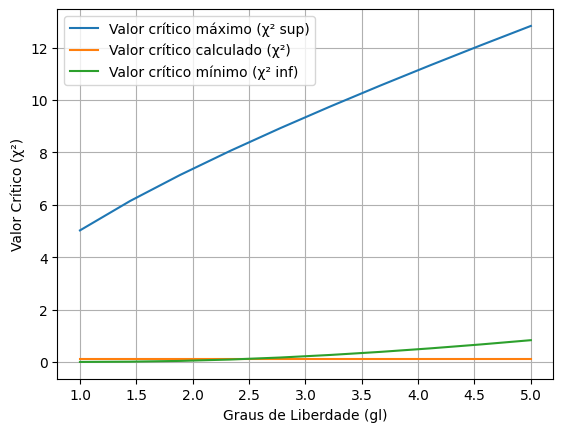

In [19]:
import matplotlib.pyplot as plt

gl = np.linspace(1, 5, 10)
signif = 0.05
quimax = chi2.ppf(1-signif/2, gl)
quimin = chi2.ppf(signif/2, gl)
plt.plot(gl, quimax, label='Valor crítico máximo (χ² sup)')
plt.plot(gl, np.array([quicalc] * gl.shape[0]), label='Valor crítico calculado (χ²)')
plt.plot(gl, quimin, label='Valor crítico mínimo (χ² inf)')
plt.xlabel('Graus de Liberdade (gl)')
plt.ylabel('Valor Crítico (χ²)')
plt.grid()
plt.legend()

## Lista de exercícios complementares